In [34]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from sklearn.model_selection import GroupShuffleSplit
from google.colab import drive
import glob

drive.mount('/content/drive')
DATA_PATH = '/content/drive/MyDrive/ds006148'
ANNOTATION_PATH = os.path.join(DATA_PATH, 'participants.tsv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Total labeled subjects: 246
Amyloid_status
Negative    140
Young        62
Positive     44
Name: count, dtype: int64


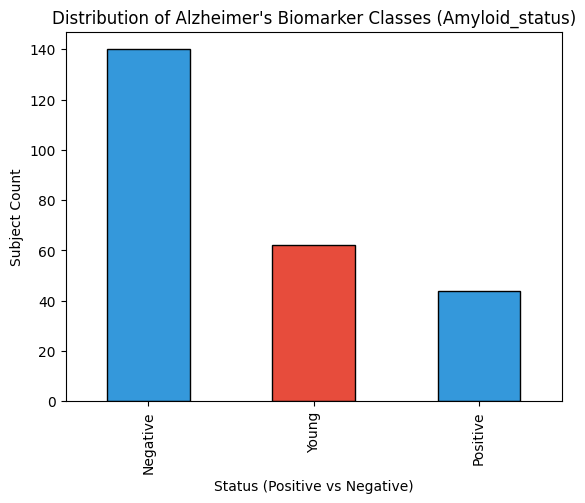

In [35]:
df_clinical = pd.read_csv(os.path.join(DATA_PATH, 'QNLD_cognitive_scores_logfile.csv'))
target_col = 'Amyloid_status'

df_clean = df_clinical.dropna(subset=[target_col])
class_counts = df_clean[target_col].value_counts()

print(f"Total labeled subjects: {len(df_clean)}")
print(class_counts)

class_counts.plot(kind='bar', color=['#3498db', '#e74c3c'], edgecolor='black')
plt.title(f'Distribution of Alzheimer\'s Biomarker Classes ({target_col})')
plt.ylabel('Subject Count')
plt.xlabel('Status (Positive vs Negative)')
plt.show()

In [36]:
target_label = 'Amyloid_status'
subject_id_col = 'ID'

df_clean = df_clinical.dropna(subset=[target_label])
gss = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=42)
train_idx, test_idx = next(gss.split(df_clean,
                                     groups=df_clean[subject_id_col]))

train_df = df_clean.iloc[train_idx]
test_df = df_clean.iloc[test_idx]

print(f"Total Subjects for Research: {len(df_clean)}")
print(f"Training Set: {len(train_df)} subjects")
print(f"Testing Set: {len(test_df)} subjects")

overlap = set(train_df[subject_id_col]).intersection(set(test_df[subject_id_col]))
print(f"Subject Leakage Check: {'There are overlapping IDs' if overlap else 'There are no overlapping IDs'}")

print("\nTraining Class Distribution (%): ")
print(train_df[target_label].value_counts(normalize=True) * 100)

Total Subjects for Research: 246
Training Set: 196 subjects
Testing Set: 50 subjects
Subject Leakage Check: There are no overlapping IDs

Training Class Distribution (%): 
Amyloid_status
Negative    57.142857
Young       26.530612
Positive    16.326531
Name: proportion, dtype: float64


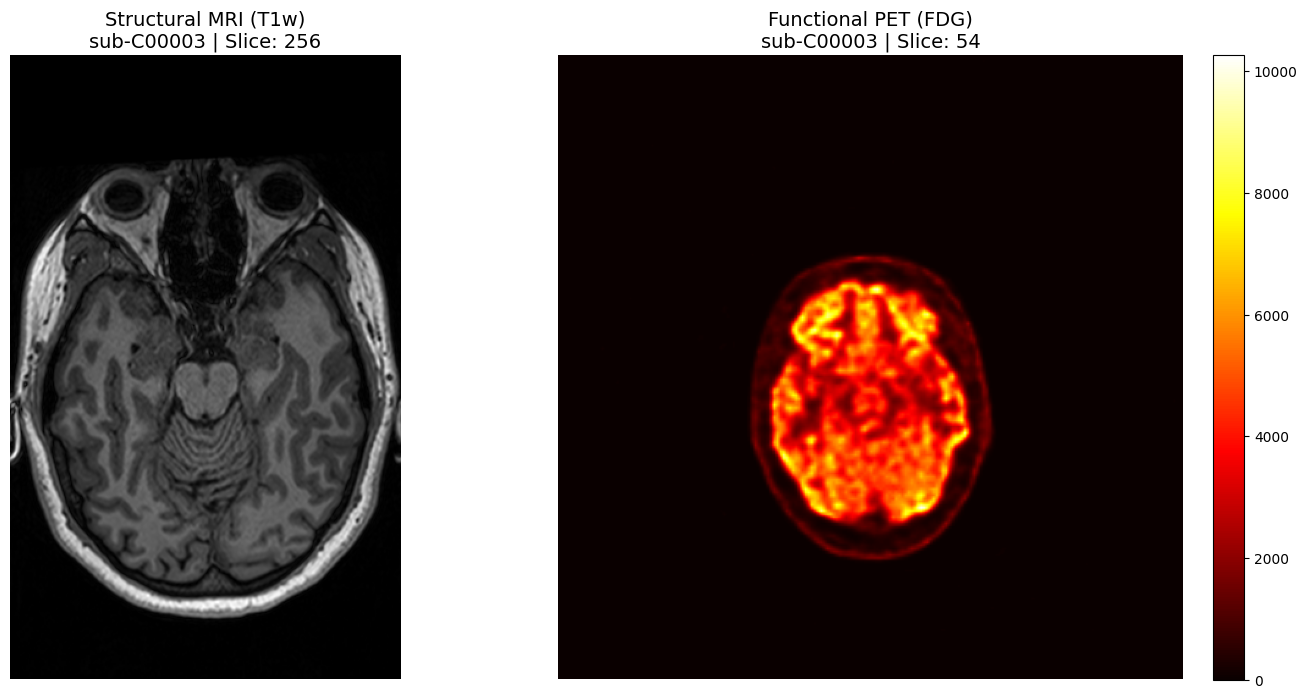

In [37]:
def plot_multimodal_slice(subject_id, session_id='ses-S001'):
    """
    Plots MRI and PET slices side-by-side for a specific subject.
    """
    subject_path = os.path.join(DATA_PATH, subject_id, session_id)
    mri_pattern = os.path.join(subject_path, 'anat', '*T1w.nii.gz')
    pet_pattern = os.path.join(subject_path, 'pet', '*_pet.nii.gz')
    mri_matches = glob.glob(mri_pattern)
    pet_matches = glob.glob(pet_pattern)
    if not mri_matches or not pet_matches:
        print(f"Missing data for {subject_id}: MRI={len(mri_matches)}, PET={len(pet_matches)}")
        return

    mri_img = nib.load(mri_matches[0]).get_fdata()
    pet_img = nib.load(pet_matches[0]).get_fdata()
    if pet_img.ndim == 4:
        pet_img = np.mean(pet_img, axis=3)

    fig, axes = plt.subplots(1, 2, figsize=(15, 7))
    mri_slice_idx = mri_img.shape[2] // 2
    pet_slice_idx = pet_img.shape[2] // 2
    axes[0].imshow(np.rot90(mri_img[:, :, mri_slice_idx]), cmap='gray')
    axes[0].set_title(f"Structural MRI (T1w)\n{subject_id} | Slice: {mri_slice_idx}", fontsize=14)
    axes[0].axis('off')
    im_pet = axes[1].imshow(np.rot90(pet_img[:, :, pet_slice_idx]), cmap='hot')
    axes[1].set_title(f"Functional PET (FDG)\n{subject_id} | Slice: {pet_slice_idx}", fontsize=14)
    axes[1].axis('off')
    plt.colorbar(im_pet, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

plot_multimodal_slice("sub-C00003")

### **5. Research Scope**

We will use the ds006148 dataset to develop and train our primary model, including our multimodal fusion testing. For external cohort validation of our proposed Disease-Acquisition Latent Factorization, we have applied for access to the ADNI dataset; however, as access has not yet been granted, we were unable to include it in this deliverable.

Factorization Scope:
We are moving toward a baseline implementation where the latent space is explicitly decomposed into:

Disease Latent: Derived from diagnostic groups (AD/MCI/CN).

Acquisition Latent: In this baseline, we use Session ID or Age Groups as proxies for acquisition variance, aiming to reduce residual leakage into the disease representation.